<a href="https://colab.research.google.com/github/Swag-Pseudopy/Escaping-Preference-Collapse/blob/main/nlhf_simulations.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

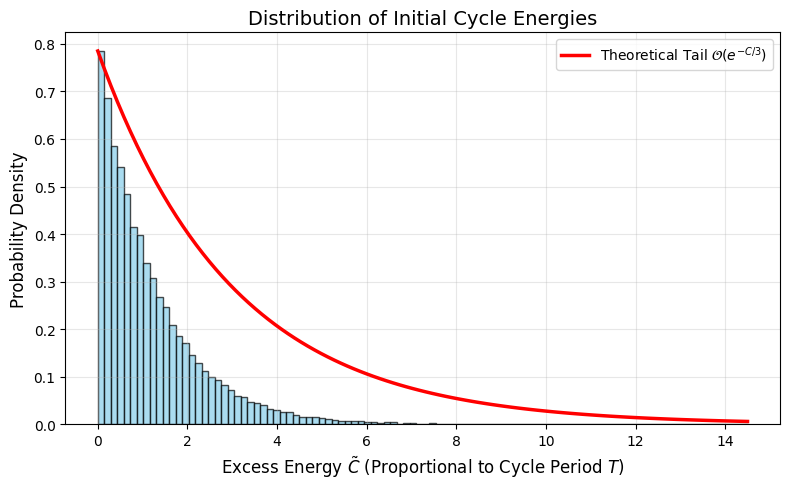

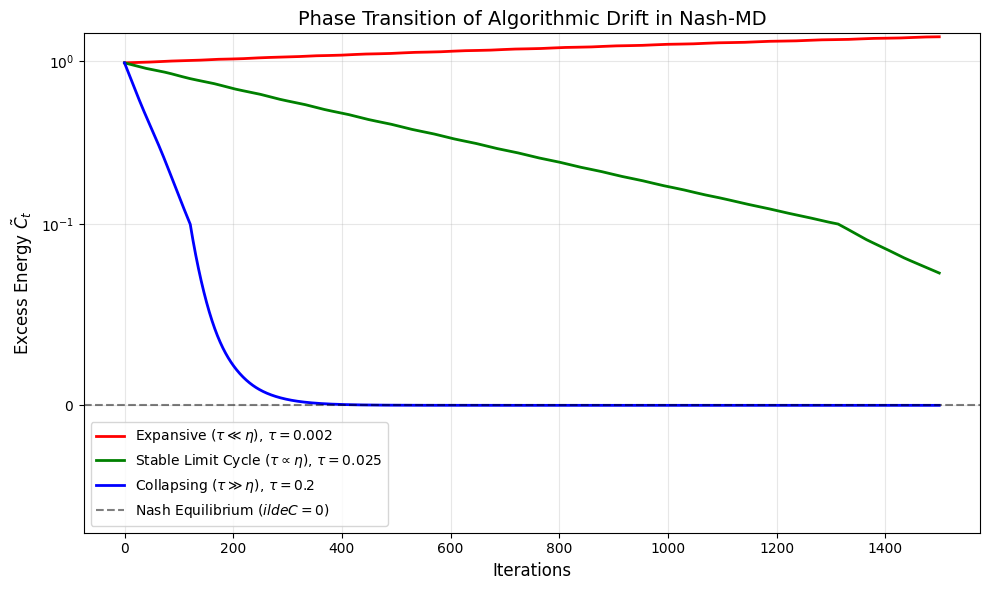

In [2]:
import numpy as np
import matplotlib.pyplot as plt

# ==========================================
# Experiment 1: Verifying Lemma 2 (Exponential Tail)
# ==========================================
def simulate_initial_distribution(n_samples=50000):
    # Sample uniformly from the 3-simplex (Dirichlet with alpha=[1,1,1])
    p_initial = np.random.dirichlet([1, 1, 1], size=n_samples)

    # Calculate initial energy C = -log(p1 * p2 * p3)
    # The Nash equilibrium energy is C_min = 3 * log(3)
    C_min = 3 * np.log(3)
    C = -np.sum(np.log(p_initial), axis=1)

    # Calculate excess energy (which scales linearly with cycle length T)
    excess_C = C - C_min

    plt.figure(figsize=(8, 5))
    count, bins, ignored = plt.hist(excess_C, bins=100, density=True, color='skyblue', edgecolor='black', alpha=0.7)

    # Overlay the theoretical exponential tail O(e^{-C/3})
    x = np.linspace(0, max(excess_C), 100)
    # Fit constant alpha for visual comparison
    alpha = count[0]
    plt.plot(x, alpha * np.exp(-x / 3), color='red', linewidth=2.5, label=r'Theoretical Tail $\mathcal{O}(e^{-C/3})$')

    plt.title("Distribution of Initial Cycle Energies", fontsize=14)
    plt.xlabel(r"Excess Energy $\tilde{C}$ (Proportional to Cycle Period $T$)", fontsize=12)
    plt.ylabel("Probability Density", fontsize=12)
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.savefig("lemma2_distribution.png", dpi=300, bbox_inches='tight')
    plt.show()

# ==========================================
# Experiment 2: Verifying Theorem 1 (Phase Transition)
# ==========================================
def nash_md_update(p, A, eta, tau):
    """Performs one discrete step of Nash-MD with KL regularization."""
    p_ref = np.array([1/3, 1/3, 1/3])
    # Compute exponents: (1 - eta*tau)*log(p) + eta*tau*log(p_ref) + eta*(A*p)
    log_unnormalized = (1 - eta * tau) * np.log(p) + (eta * tau) * np.log(p_ref) + eta * (A @ p)

    # Numerically stable softmax
    log_unnormalized -= np.max(log_unnormalized)
    p_next = np.exp(log_unnormalized)
    return p_next / np.sum(p_next)

def simulate_phase_transition(iterations=1500):
    # Condorcet Skew-Symmetric Matrix (Rock-Paper-Scissors)
    A = np.array([[ 0,  1, -1],
                  [-1,  0,  1],
                  [ 1, -1,  0]])

    eta = 0.05 # Fixed learning rate

    # Three regimes of regularization
    taus = {
        r"Expansive ($\tau \ll \eta$)": 0.002,
        r"Stable Limit Cycle ($\tau \propto \eta$)": 0.025,
        r"Collapsing ($\tau \gg \eta$)": 0.2
    }

    # Initialize policy away from the center to clearly see the drift
    p_start = np.array([0.7, 0.2, 0.1])
    C_min = 3 * np.log(3)

    trajectories = {label: [] for label in taus.keys()}

    for label, tau in taus.items():
        p = p_start.copy()
        for _ in range(iterations):
            # Record excess energy
            C = -np.sum(np.log(p)) - C_min
            trajectories[label].append(C)
            # Update policy
            p = nash_md_update(p, A, eta, tau)

    # Plotting
    plt.figure(figsize=(10, 6))
    colors = ['red', 'green', 'blue']
    for (label, traj), color in zip(trajectories.items(), colors):
        plt.plot(traj, label=f"{label}, $\\tau={taus[label]}$", color=color, linewidth=2)

    plt.axhline(0, color='black', linestyle='--', alpha=0.5, label="Nash Equilibrium ($\tilde{C}=0$)")
    plt.title("Phase Transition of Algorithmic Drift in Nash-MD", fontsize=14)
    plt.xlabel("Iterations", fontsize=12)
    plt.ylabel(r"Excess Energy $\tilde{C}_t$", fontsize=12)
    plt.yscale("symlog", linthresh=0.1) # Symlog handles the approach to zero elegantly
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.savefig("theorem1_phasetransition.png", dpi=300, bbox_inches='tight')
    plt.show()

if __name__ == "__main__":
    simulate_initial_distribution()
    simulate_phase_transition()